In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df=pd.read_csv(r'master_time_table.csv')
df['cycle_start_time']=pd.to_datetime(df['cycle_start_time'])
df['cycle_end_time']=pd.to_datetime(df['cycle_end_time'])
df

,run_id,cycle_id,cycle_start_time,cycle_end_time,cycle_time_sec,avg_vfd1_temp,avg_vfd2_temp,avg_vfd3_temp,avg_vfd4_temp,avg_r01_load,...,avg_r04_load,min_r04_load,max_r04_load,stopper1_active_count,stopper2_active_count,stopper3_active_count,stopper4_active_count,stopper5_active_count,defect_label,defect_flag
0,1,1,2023-12-11 13:04:12.348,2023-12-11 13:09:07.045,294,71.233424,-1.370384e+34,-9.216491e+33,2.700136e+26,492.254410,...,3449.915536,1366,13917,169,645,15,15,56,NaN,0
1,1,2,2023-12-11 13:09:07.143,2023-12-11 13:14:02.039,294,75.764047,3.102370e+34,1.598492e+31,-2.152555e+27,495.950508,...,3497.553898,1401,13868,168,644,15,16,56,NaN,0
2,1,3,2023-12-11 13:14:02.154,2023-12-11 13:18:57.142,294,78.823626,-6.456377e+29,5.120403e+34,-8.300746e+28,493.364746,...,3580.584746,1333,13707,169,644,15,15,55,NaN,0
3,2,1,2023-12-11 13:49:56.648,2023-12-11 13:54:50.838,294,73.863440,-1.111724e+29,-1.264015e+34,-5.704415e+32,492.903840,...,3563.291539,1511,14086,169,644,15,15,51,NaN,0
4,2,2,2023-12-11 13:54:50.976,2023-12-11 13:59:46.161,295,78.016718,-6.303720e+33,9.776341e+34,9.113340e+32,467.205693,...,2733.844798,333,13711,168,644,15,15,55,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
322,6,271,2023-12-12 17:43:10.037,2023-12-12 17:48:04.343,294,89.872614,2.705198e+33,-4.347826e+34,4.551655e+33,391.248302,...,-2.841372,-1510,1476,168,644,15,15,55,NoNose,1
323,6,272,2023-12-12 17:48:04.445,2023-12-12 17:52:58.976,294,89.889933,-4.648071e+32,-4.509786e+34,7.180239e+31,390.743294,...,-7.990492,-1489,1482,168,644,15,15,55,NoNose,1
324,6,273,2023-12-12 17:52:58.978,2023-12-12 17:57:53.348,294,89.895697,9.883118e+31,1.977609e+32,-6.517012e+34,383.656367,...,7.943973,-1448,1467,169,644,15,15,55,NoNose,1
325,6,274,2023-12-12 17:57:53.439,2023-12-12 18:02:48.054,294,89.911082,-6.775624e+32,-9.402668e+34,-2.172456e+34,391.298371,...,8.686015,-1467,1484,168,644,15,15,55,NoNose,1


In [8]:
temp_cols=['avg_vfd1_temp','avg_vfd2_temp','avg_vfd3_temp','avg_vfd4_temp']
for col in temp_cols:
    df[col]=pd.to_numeric(df[col],errors='coerce')
    df.loc[(df[col]<40) | (df[col]>120),col]=np.nan   
df

NameError: name 'df' is not defined

In [15]:
df['defect_flag'].value_counts()


defect_flag
1    165
0    162
Name: count, dtype: int64

In [16]:
df['defect_label'].value_counts()

defect_label
NoNose                    60
NoNose|NoBody2|NoBody1    54
NoNose|NoBody2            51
Name: count, dtype: int64

In [17]:
df.groupby('defect_label')['cycle_time_sec'].describe()

,count,mean,std,min,25%,50%,75%,max
defect_label,,,,,,,,
NoNose,60.0,295.633333,44.691776,6.0,294.0,294.0,295.0,446.0
NoNose|NoBody2,51.0,301.156863,12.866037,293.0,294.0,294.0,304.0,359.0
NoNose|NoBody2|NoBody1,54.0,298.018519,11.674017,293.0,294.0,294.0,294.0,357.0


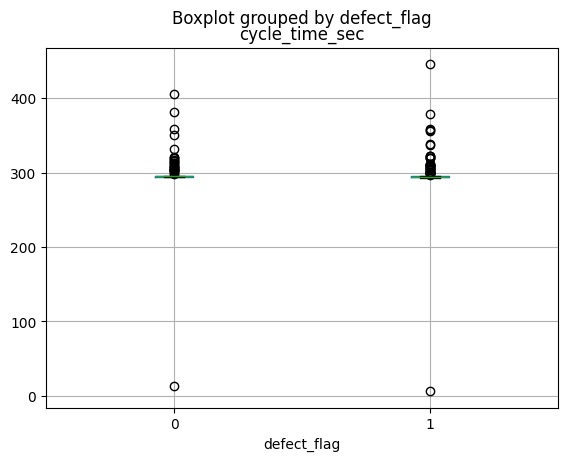

In [19]:
df.boxplot(column='cycle_time_sec', by='defect_flag')
plt.show()

In [20]:
load_cols=[
    'avg_r01_load',
    'avg_r02_load',
    'avg_r03_load',
    'avg_r04_load'
]

df.groupby('defect_flag')[load_cols].mean()

,avg_r01_load,avg_r02_load,avg_r03_load,avg_r04_load
defect_flag,,,,
0,377.678961,1304.967737,1849.478738,181.510374
1,409.404990,1308.208890,1657.812457,388.714598


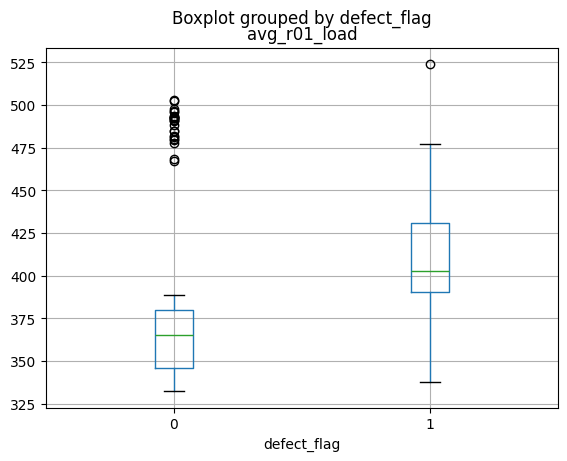

In [21]:
df.boxplot(column='avg_r01_load', by='defect_flag')
plt.show()

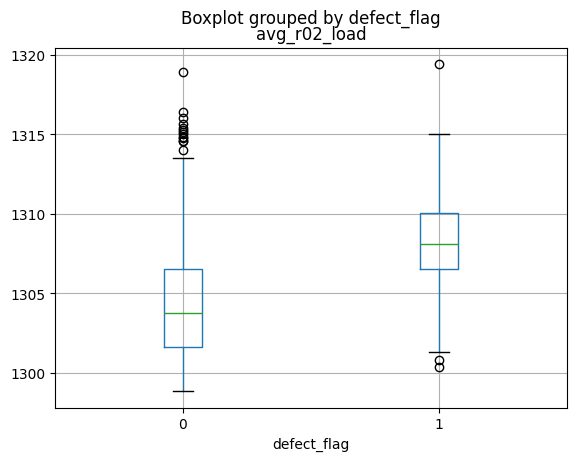

In [22]:
df.boxplot(column='avg_r02_load', by='defect_flag')
plt.show()

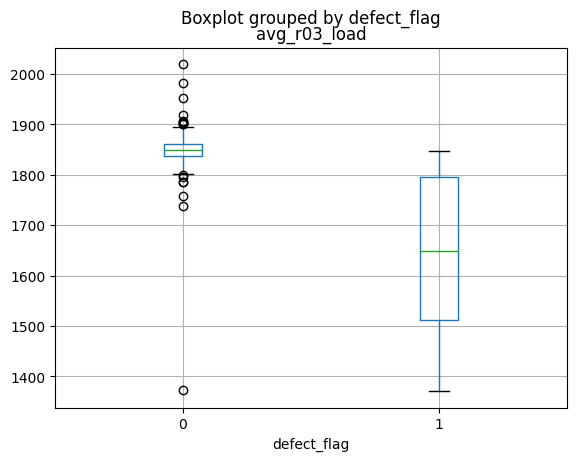

In [23]:
df.boxplot(column='avg_r03_load', by='defect_flag')
plt.show()

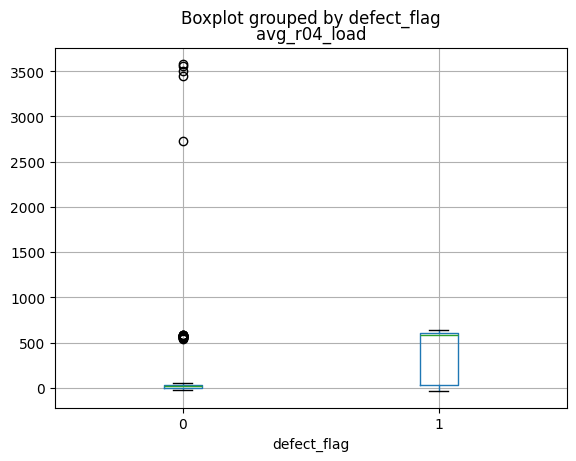

In [24]:
df.boxplot(column='avg_r04_load', by='defect_flag')
plt.show()

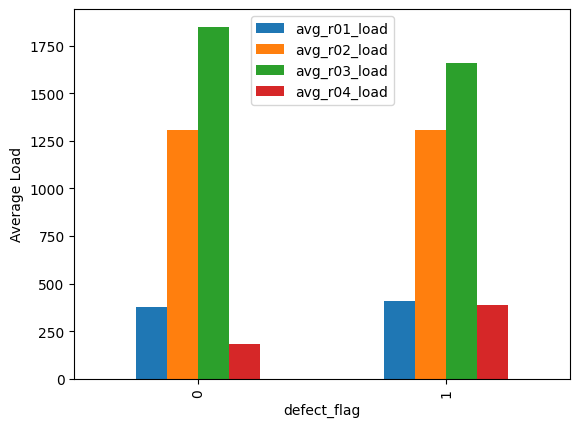

In [26]:
load_cols=['avg_r01_load','avg_r02_load','avg_r03_load','avg_r04_load']

df.groupby('defect_flag')[load_cols].mean().plot(kind='bar')
plt.ylabel("Average Load")
plt.show()

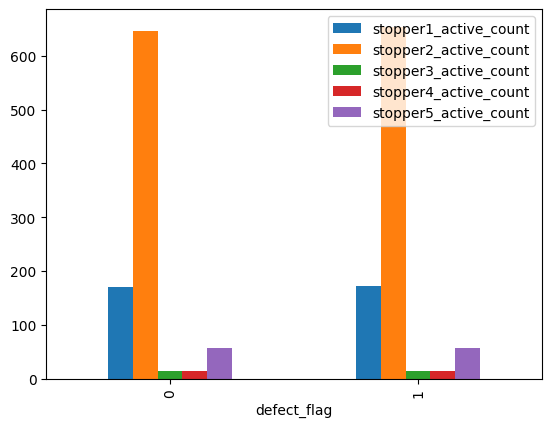

In [27]:
stop_cols=[
'stopper1_active_count',
'stopper2_active_count',
'stopper3_active_count',
'stopper4_active_count',
'stopper5_active_count'
]

df.groupby('defect_flag')[stop_cols].mean().plot(kind='bar')
plt.show()

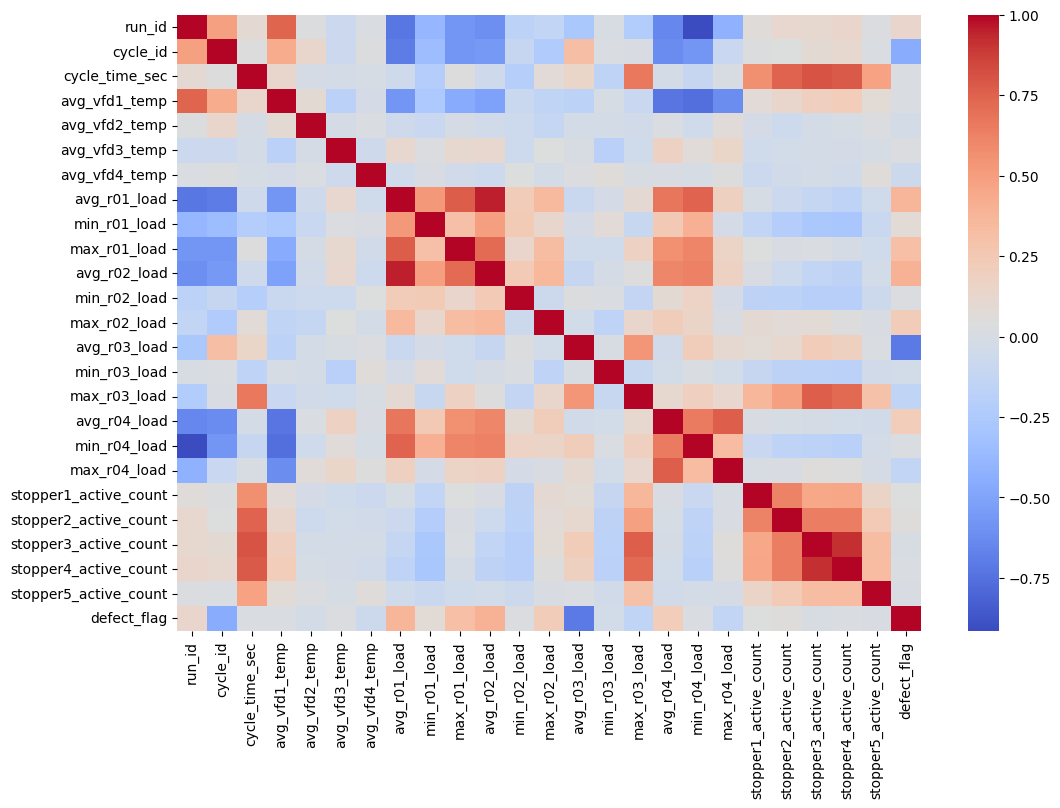

In [10]:

num_df=df.select_dtypes(include='number')

plt.figure(figsize=(12,8))
sns.heatmap(num_df.corr(), cmap='coolwarm')
plt.show()

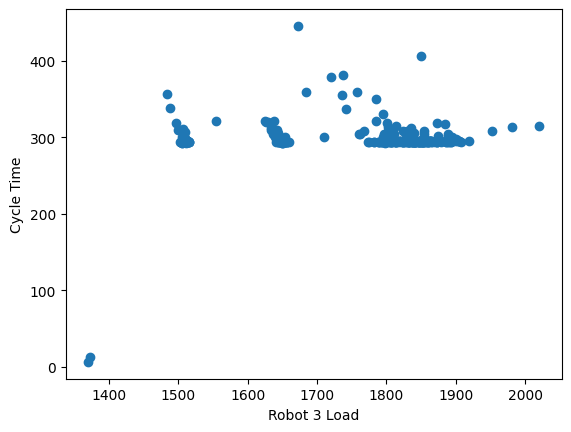

In [11]:
plt.scatter(df['avg_r03_load'], df['cycle_time_sec'])
plt.xlabel("Robot 3 Load")
plt.ylabel("Cycle Time")
plt.show()

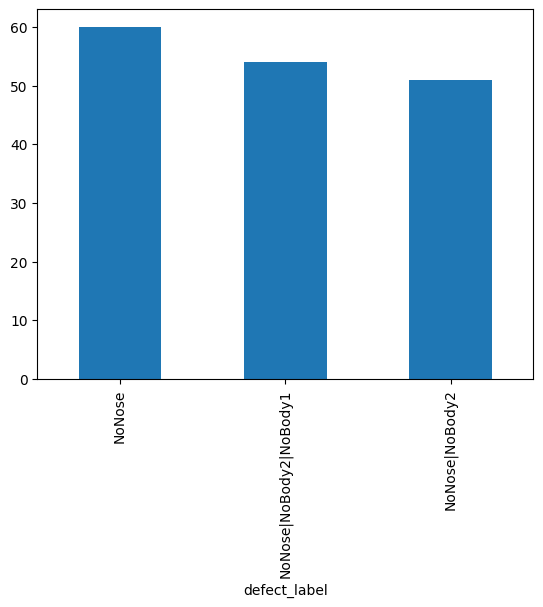

In [12]:
defects=df['defect_label'].value_counts()
defects.plot(kind='bar')
plt.show()